In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import logging
from tqdm.notebook import tqdm
from engine.models import TargetFunction
from engine.optimizers.population_based import GeneticAlgorithm
from engine.initializers import RandomInitializer
from engine.strategies.selection import TournamentSelection, ElitismSelection, RouletteWheelSelection
from engine.strategies.mutation import RealCodedMutation
from engine.strategies.crossover import UniformCrossover

functions = {
    "Levy_13": {
        "expr": "sin(3*pi*x)**2 + (x-1)**2 * (1 + sin(3*pi*y)**2) + (y-1)**2 * (1 + sin(2*pi*y)**2)",
        "bounds": [(-10, 10), (-10, 10)],
        "min": np.array([1.0, 1.0]),
        "f_min": 0.0
    },
    "Eggholder": {
        "expr": "-(y+47)*sin(sqrt(abs(x/2 + y + 47))) - x*sin(sqrt(abs(x - (y + 47))))",
        "bounds": [(-512, 512), (-512, 512)],
        "min": np.array([512.0, 404.2319]),
        "f_min": -959.6407
    }
}

# The Experiment Configuration
selection_strategies = [TournamentSelection(3), ElitismSelection(), RouletteWheelSelection()]
pop_sizes = [20, 50, 100]
n_runs = 100

results_data = []

engine_logger = logging.getLogger("engine.utils") 

engine_logger.setLevel(logging.WARNING)

for func_name, f_data in functions.items():
    target = TargetFunction(f_data['expr'], bounds=f_data['bounds'])
    
    for sel in selection_strategies:
        for p in pop_sizes:
            errors = []
            iterations_needed = []
            
            desc = f"{func_name} | {sel.__class__.__name__} | Pop={p}"
            for _ in tqdm(range(n_runs), desc=desc, leave=True):
                ga = GeneticAlgorithm(
                    target, p, RandomInitializer(), sel, UniformCrossover(), 
                    RealCodedMutation(), phi_sel=0.2, phi_cross=0.6, phi_mut=0.2,
                        stopping_criterion='stagnation', patience=10
                )
                res = ga.run(max_iter=500)
                
                # Calculate metrics
                # Since 'res' is already populated by ga.run, we use its final_population
                best_idx = np.argmin([target.evaluate(p) for p in res.final_population])
                best_x = res.final_population[best_idx]
                dist = np.linalg.norm(best_x - f_data['min'])
                
                errors.append(dist)
                iterations_needed.append(res.iterations)
            
            # Append results for this specific configuration
            results_data.append({
                "Function": func_name,
                "Selection": sel.__class__.__name__,
                "PopSize": p,
                "AvgDist": np.mean(errors),
                "AvgIters": np.mean(iterations_needed)
            })

# Convert to DataFrame
df = pd.DataFrame(results_data)
print(df)

Levy_13 | TournamentSelection | Pop=20:   0%|          | 0/100 [00:00<?, ?it/s]

Levy_13 | TournamentSelection | Pop=50:   0%|          | 0/100 [00:00<?, ?it/s]

Levy_13 | TournamentSelection | Pop=100:   0%|          | 0/100 [00:00<?, ?it/s]

Levy_13 | ElitismSelection | Pop=20:   0%|          | 0/100 [00:00<?, ?it/s]

Levy_13 | ElitismSelection | Pop=50:   0%|          | 0/100 [00:00<?, ?it/s]

...

Eggholder | ElitismSelection | Pop=100:   0%|          | 0/100 [00:00<?, ?it/s]

Eggholder | RouletteWheelSelection | Pop=20:   0%|          | 0/100 [00:00<?, ?it/s]

Eggholder | RouletteWheelSelection | Pop=50:   0%|          | 0/100 [00:00<?, ?it/s]

Eggholder | RouletteWheelSelection | Pop=100:   0%|          | 0/100 [00:00<?, ?it/s]

     Function               Selection  PopSize     AvgDist  AvgIters
0     Levy_13     TournamentSelection       20    0.772280     26.90
1     Levy_13     TournamentSelection       50    0.148701     39.35
2     Levy_13     TournamentSelection      100    0.063251     43.44
3     Levy_13        ElitismSelection       20    0.151280     76.75
4     Levy_13        ElitismSelection       50    0.007316     61.66
5     Levy_13        ElitismSelection      100    0.000512     59.14
6     Levy_13  RouletteWheelSelection       20    1.712543     18.50
7     Levy_13  RouletteWheelSelection       50    0.791358     22.79
8     Levy_13  RouletteWheelSelection      100    0.411934     24.54
9   Eggholder     TournamentSelection       20  697.357459     16.31
10  Eggholder     TournamentSelection       50  795.125676     16.10
11  Eggholder     TournamentSelection      100  762.559859     15.84
12  Eggholder        ElitismSelection       20  638.980173    153.70
13  Eggholder        ElitismSelect

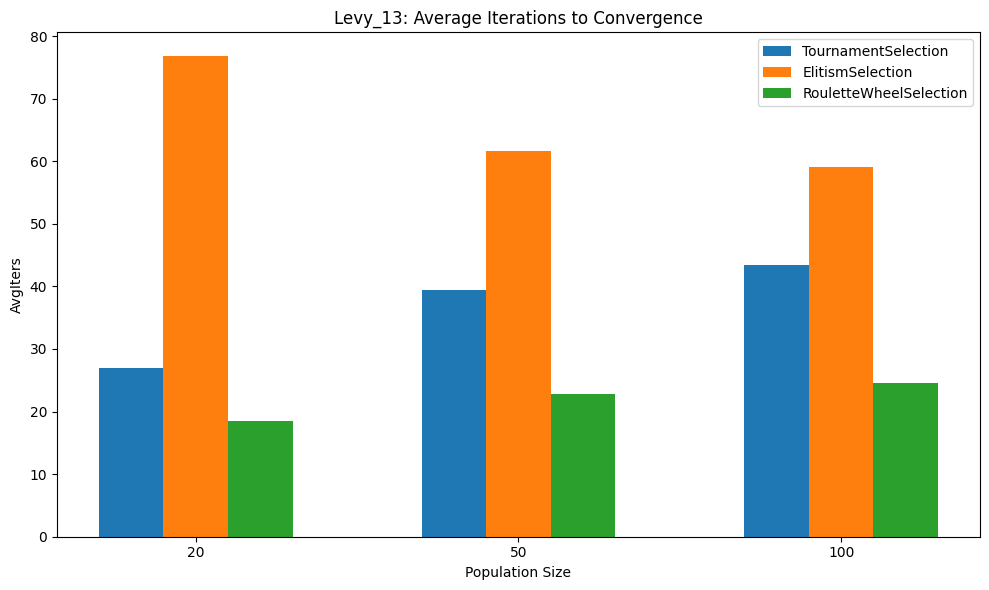

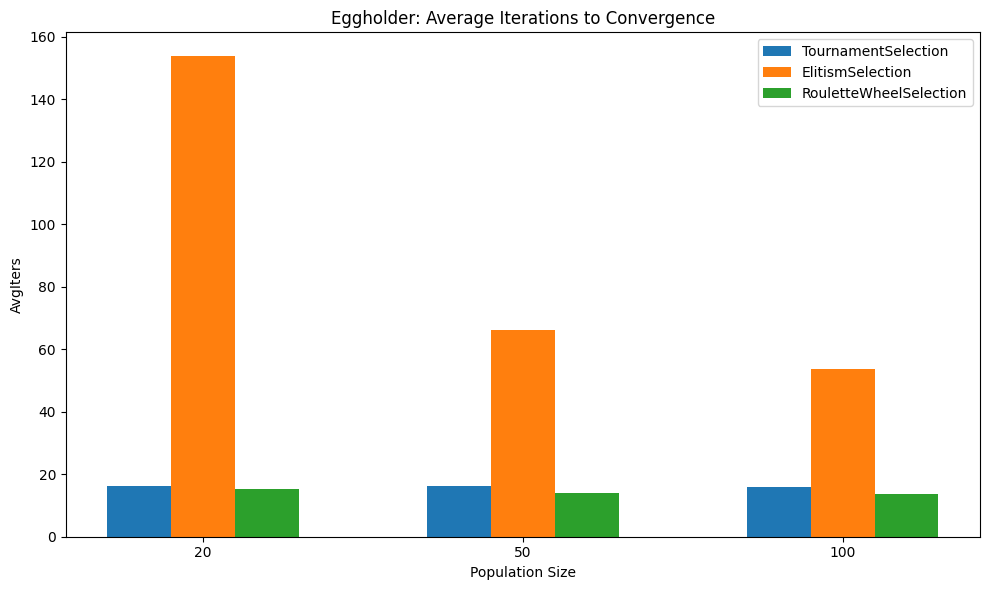

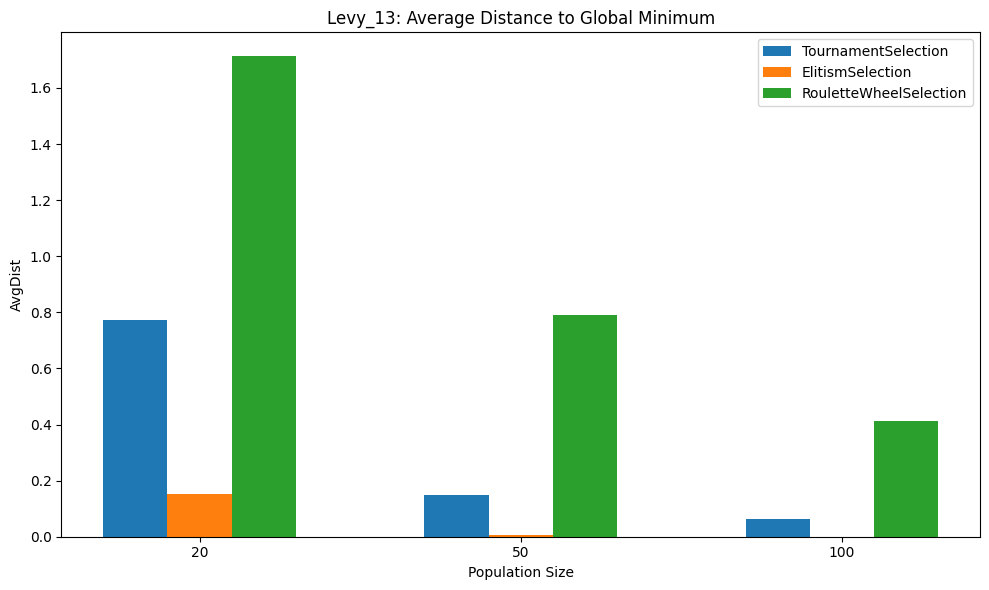

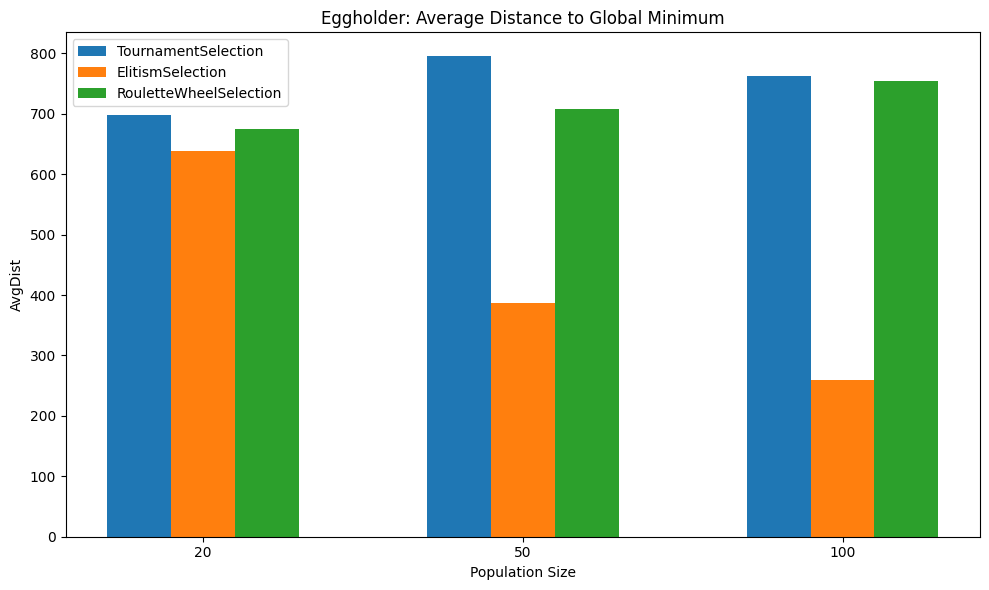

In [11]:
import matplotlib.pyplot as plt
import re # Added for safe filename formatting

def plot_results(df, metric, title_suffix):
    functions = df['Function'].unique()
    
    for func in functions:
        subset = df[df['Function'] == func]
        pop_sizes = sorted(subset['PopSize'].unique())
        strategies = subset['Selection'].unique()
        
        # Setup bar positions
        x = np.arange(len(pop_sizes))
        width = 0.2
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot bars for each strategy
        for i, strategy in enumerate(strategies):
            data = subset[subset['Selection'] == strategy].sort_values('PopSize')[metric]
            ax.bar(x + (i - 1) * width, data, width, label=strategy)
            
        ax.set_ylabel(metric)
        ax.set_xlabel('Population Size')
        ax.set_title(f'{func}: {title_suffix}')
        ax.set_xticks(x)
        ax.set_xticklabels(pop_sizes)
        ax.legend()
        plt.tight_layout()
        
        # Save the image
        filename = f"{func}_{metric}_bar.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        
        # Show in notebook
        plt.show()

# Generate the two requested plots
plot_results(df, 'AvgIters', 'Average Iterations to Convergence')
plot_results(df, 'AvgDist', 'Average Distance to Global Minimum')

In [18]:
import re
import matplotlib.pyplot as plt

def plot_fisels(df, metric, title_suffix):
    functions = df['Function'].unique()
    strategies = df['Selection'].unique()
    
    # Loop through each function so they don't get mixed on the same graph
    for func in functions:
        subset = df[df['Function'] == func]
        
        plt.figure(figsize=(8, 6))
        
        for strategy in strategies:
            strat_data = subset[subset['Selection'] == strategy].sort_values('Fi_sel')
            plt.plot(strat_data['Fi_sel'], strat_data[metric], marker='o', label=strategy)
            
        plt.title(f"{func}: {title_suffix}")
        plt.xlabel('Fi_sel')
        plt.ylabel(metric)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.grid(True)
        
        # Save the image dynamically
        safe_title = re.sub(r'[^A-Za-z0-9_]', '_', f"{func}_{title_suffix}".replace(' ', '_'))
        filename = f"{safe_title}.png"
        
        # bbox_inches='tight' ensures the outside legend isn't cut off in the saved image
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        
        plt.show()

In [14]:
# 1. Configuration for the new experiment
phi_sel_values = [0.1, 0.2, 0.3, 0.4, 0.5]
pop_size_fixed = 100
n_runs = 100 

results_data = []

# 2. Experiment Loop
for func_name, f_data in functions.items():
    target = TargetFunction(f_data['expr'], bounds=f_data['bounds'])
    
    for sel in selection_strategies:
        for phi in tqdm(phi_sel_values, desc=f"{func_name} | {sel.__class__.__name__}"):
            errors = []
            iterations_needed = []
            
            for _ in range(n_runs):
                # Using dynamic mutation sigma: 5% of the total search space width
                width = f_data['bounds'][0][1] - f_data['bounds'][0][0]
                mut = RealCodedMutation(sigma=width * 0.05)
                
                ga = GeneticAlgorithm(
                    target_function=target,
                    population_size=pop_size_fixed,
                    initializer=RandomInitializer(),
                    selection_strategy=sel,
                    crossover_strategy=UniformCrossover(),
                    mutation_strategy=mut,
                    phi_sel=phi, 
                    phi_cross=1.0 - phi - 0.1, # Keep mut fixed at 0.1
                    phi_mut=0.1,
                    stopping_criterion='stagnation',
                    patience=10
                )
                
                res = ga.run(max_iter=500)
                
                # Metrics
                best_idx = np.argmin([target.evaluate(p) for p in res.final_population])
                best_x = res.final_population[best_idx]
                dist = np.linalg.norm(best_x - f_data['min'])
                
                errors.append(dist)
                iterations_needed.append(res.iterations)
            
            results_data.append({
                "Function": func_name,
                "Selection": sel.__class__.__name__,
                "Fi_sel": phi,
                "AvgDist": np.mean(errors),
                "AvgIters": np.mean(iterations_needed)
            })

# 3. Create DataFrame
df_phi = pd.DataFrame(results_data)

Levy_13 | TournamentSelection:   0%|          | 0/5 [00:00<?, ?it/s]

Levy_13 | ElitismSelection:   0%|          | 0/5 [00:00<?, ?it/s]

Levy_13 | RouletteWheelSelection:   0%|          | 0/5 [00:00<?, ?it/s]

2026-03-16 17:03:22,093 [WARNING] Analytical gradient not available for '-(y+47)*sin(sqrt(abs(x/2 + y + 47))) - x*sin(sqrt(abs(x - (y + 47))))': Unsupported by <class 'sympy.printing.numpy.NumPyPrinter'>: <class 'sympy.core.function.Derivative'>
Printer has no method: _print_Derivative_im
Set the printer option 'strict' to False in order to generate partially printed code.. Using numerical fallback.


Eggholder | TournamentSelection:   0%|          | 0/5 [00:00<?, ?it/s]

Eggholder | ElitismSelection:   0%|          | 0/5 [00:00<?, ?it/s]

Eggholder | RouletteWheelSelection:   0%|          | 0/5 [00:00<?, ?it/s]

     Function               Selection  Fi_sel     AvgDist  AvgIters
0     Levy_13     TournamentSelection     0.1    0.236243     28.62
1     Levy_13     TournamentSelection     0.2    0.043461     39.49
2     Levy_13     TournamentSelection     0.3    0.015620     56.05
3     Levy_13     TournamentSelection     0.4    0.007884     55.25
4     Levy_13     TournamentSelection     0.5    0.004321     56.27
5     Levy_13        ElitismSelection     0.1    0.006104     51.65
6     Levy_13        ElitismSelection     0.2    0.000347     58.83
7     Levy_13        ElitismSelection     0.3    0.000811     53.48
8     Levy_13        ElitismSelection     0.4    0.000003     55.88
9     Levy_13        ElitismSelection     0.5    0.005918     57.48
10    Levy_13  RouletteWheelSelection     0.1    0.595741     24.87
11    Levy_13  RouletteWheelSelection     0.2    0.425891     24.74
12    Levy_13  RouletteWheelSelection     0.3    0.351516     26.19
13    Levy_13  RouletteWheelSelection     0.4   

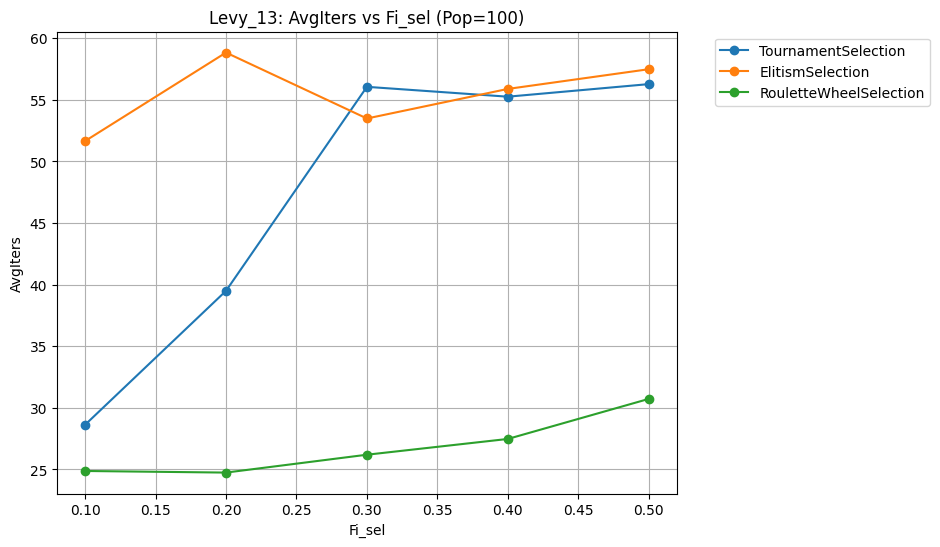

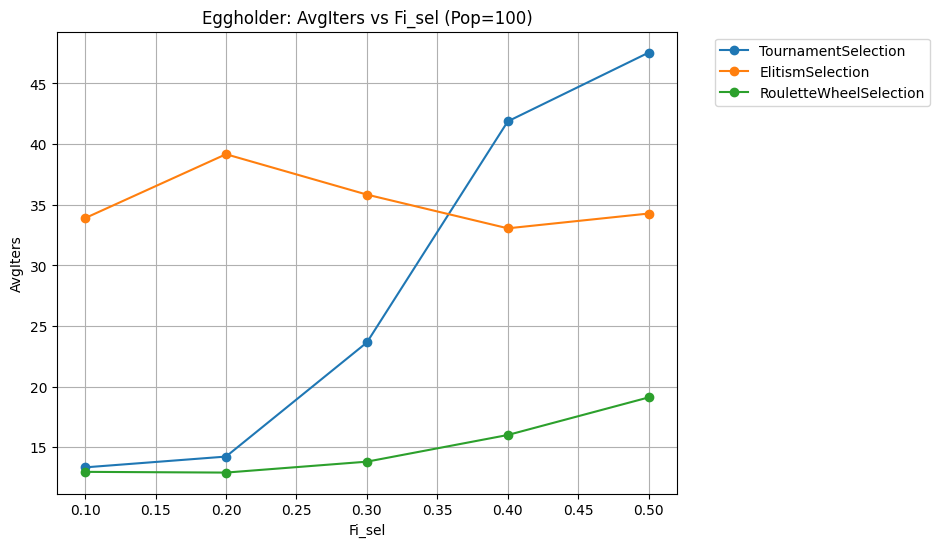

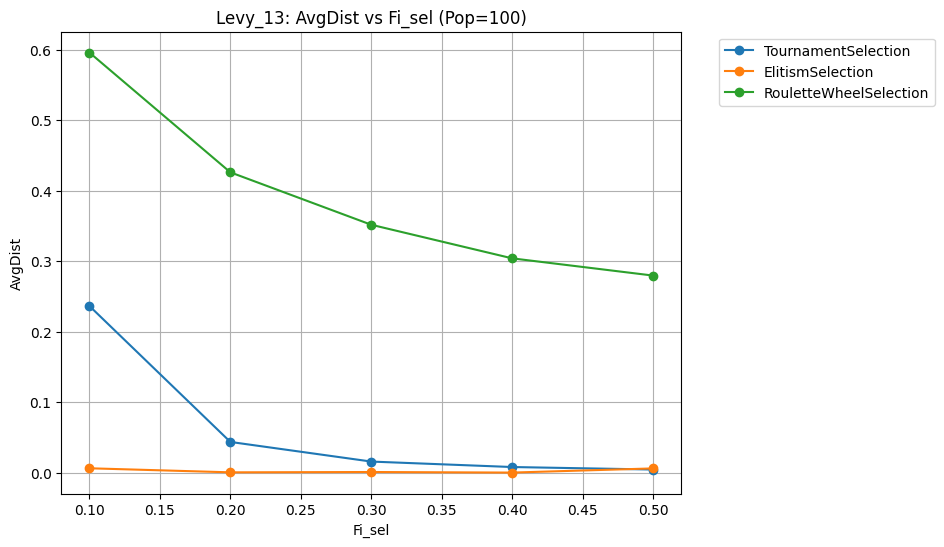

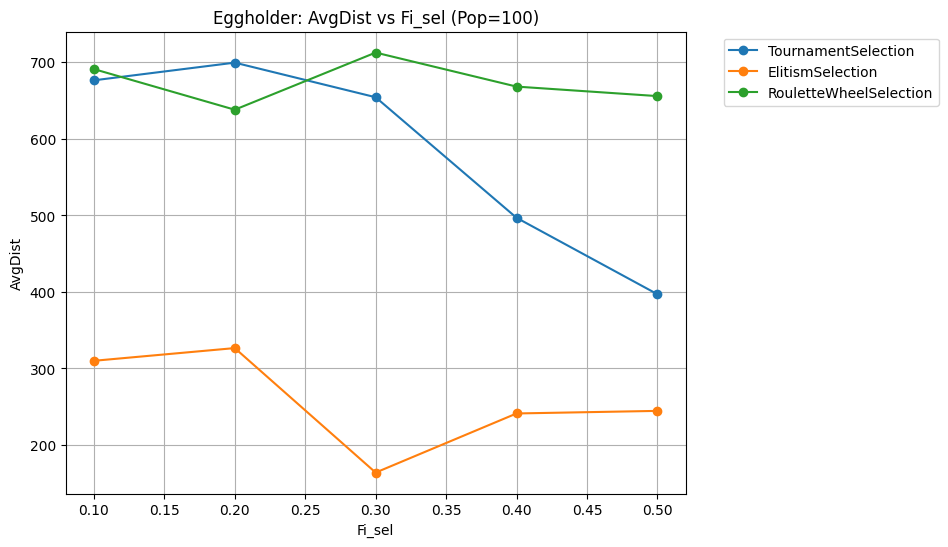

In [19]:
print(df_phi)

# 4. Plot the results
plot_fisels(df_phi, 'AvgIters', 'AvgIters vs Fi_sel (Pop=100)')

import matplotlib.pyplot as plt

def plot_fisels(df, metric, title_suffix):
    functions = df['Function'].unique()
    strategies = df['Selection'].unique()
    
    # Loop through each function so they don't get mixed on the same graph
    for func in functions:
        subset = df[df['Function'] == func]
        
        plt.figure(figsize=(8, 6))
        
        for strategy in strategies:
            strat_data = subset[subset['Selection'] == strategy].sort_values('Fi_sel')
            plt.plot(strat_data['Fi_sel'], strat_data[metric], marker='o', label=strategy)
            
        plt.title(f"{func}: {title_suffix}")
        plt.xlabel('Fi_sel')
        plt.ylabel(metric)
        
        # --- FIX: Move legend outside the plot to the top right ---
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.grid(True)
        
        # Save the image dynamically
        safe_title = re.sub(r'[^A-Za-z0-9_]', '_', f"{func}_{title_suffix}".replace(' ', '_'))
        filename = f"{safe_title}.png"
        
        # bbox_inches='tight' ensures the outside legend isn't cut off in the saved image
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        
        plt.show()

# Call it like this (don't include the function name in the title argument anymore):
# plot_fisels(df_phi, 'AvgIters', 'AvgIters vs Fi_sel (Pop=100)')
# plot_fisels(df_phi, 'AvgDist', 'AvgDist vs Fi_sel (Pop=100)')

What changed:

    bbox_to_anchor=(1.05, 1), loc='upper left': This pushes the legend exactly to the right, completely outside the grid box. It will never cover your lines again.

    for func in functions:: This splits your data. You will now get two separate line charts (one for Levy_13 and one for Eggholder), and the lines will be smooth and horizontal-ish, without those weird vertical drops!

28.6s
info Google AI models may make mistakes, so double-check outputs.
Use Arrow Up and Arrow Down to select a turn, Enter to jump to it, and Escape to return to the chat.
plot_fisels(df_phi, 'AvgDist', 'AvgDist vs Fi_sel (Pop=100)')